In [96]:
import torch 
import torch.nn.functional as F
import matplotlib.pyplot as plt 

In [97]:
words = open('names.txt', 'r').read().splitlines()
print(words[:5])
print(len(words))


['emma', 'olivia', 'ava', 'isabella', 'sophia']
32033


In [98]:
# building the vocabulary of characters and mappings to integers
chars = sorted(list(set(''.join(words))))
string_to_index = {string:index +1 for index, string in enumerate(chars)}
string_to_index['.'] = 0
index_to_string = {index:string for string, index in string_to_index.items()}
print(index_to_string)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [99]:
# building the dataset

block_size = 3 # context_length: how many characters are taken to predict the next one
X, Y = [], []
for w in words:

    
    context = [0]* block_size
    for ch in w + '.':
        ix = string_to_index[ch]
        X.append(context)
        Y.append(ix)
        #print(''.join(index_to_string[i] for i in context), '----->', index_to_string[ix])
        context = context[1:]+ [ix] # crop and append


X = torch.tensor(X)
Y = torch.tensor(Y)

In [100]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [101]:
#Building embedding of characters
C = torch.randn((27, 2)) #lookup table with 2 dim embedding for each character
C[X].shape

 # F.one_hot(torch.tensor(5), num_classes=27) # alternative embedding 

torch.Size([228146, 3, 2])

In [102]:
emb = C[X]

# hidden layer
W1 = torch.randn((6,100))  # 2 dim embeddings for 3 input neurons ---> 6 
b1 = torch.randn(100)

h = torch.tanh(emb.view(emb.shape[0], 6) @ W1 + b1) 
print(h.shape)
#Alternatives methods
# a = torch.cat([emb[:,0,:], emb[:,1,:], emb[:,2,:]],1)
# a = torch.arange(18)    



#output layer
W2 = torch.randn((100,27))
b2 = torch.randn(27)

logits = h @ W2 + b2
# counts = logits.exp()
# prob = counts / counts.sum(1 , keepdims = True)
# loss = -prob[torch.arange(32), Y].log().mean() use F.cross_entropy for efficiency and simplicity
F.cross_entropy(logits, Y)
print(f'Loss:{loss}')


torch.Size([228146, 100])
Loss:2.6385927200317383


In [103]:
F.cross_entropy(logits, Y)

tensor(19.0038)

-----

In [104]:
# Better way 
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,2), generator = g)
W1 = torch.randn((6,100), generator= g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100,27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, W2, b1, b2]

print('Total parameters:',sum(p.nelement() for p in parameters))

Total parameters: 3481


In [105]:
lre = torch.linspace(-3 ,0 , 1000)
lrs = 10 ** lre 


In [106]:
lri = []
lossi = []
stpi = []


In [107]:
for p in parameters:
    p.requires_grad = True


lri = []
lossi = []


for i in range(100):

    #minibatch construct
    ix = torch.randint(0, X.shape[0], (32,))

    # forward pass
    emb = C[X[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32,27)
    loss = F.cross_entropy(logits, Y[ix])
    #print(loss.item())

    # backward pass
    for p in parameters: 
        p.grad = None
    loss.backward()

    # update
    lr = learn_rate_srch[i]
    for p in parameters:
        p.data += -0.1 * p.grad

    # track stats
    lri.append(lr)
    lossi.append(loss.item())


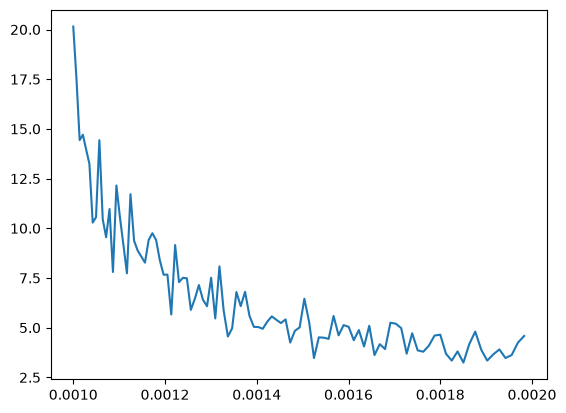

In [108]:
plt.plot(lri, lossi)